# Introduction
This section introduces the purpose of the analysis and explains why dimensionality reduction is useful for the energy dataset. We outline how Principal Component Analysis (PCA) helps simplify high-dimensional data, remove redundancy, and reveal meaningful structure within the dataset.


# Import Dependencies and Utility Functions
In this section, we import the PCA utility functions from our separate Python module, along with any additional libraries required for visualization and analysis. Separating functions from the notebook improves code organization, readability, and reusability.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from rice_ml.unsupervised_learning.dimensionality_reduction import (
    load_energy_data,
    select_numeric_features,
    scale_energy_features,
    run_energy_pca,
    get_pca_variance,
    create_pca_dataframe
)


# Load and Explore the Dataset
Here we load the energy dataset and perform a brief inspection to understand its structure. Examining the first few rows helps confirm that the file was loaded correctly and provides context for the types of variables included in the dataset.


In [2]:
# Load the energy dataset
df = load_energy_data("../../../datasets/energy.csv")
# Preview the first rows
df.head()


,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0


# Select Numeric Features and Scale the Data
PCA operates only on numerical data; therefore, we extract the numeric columns from the dataset. We also standardize the features so that each one contributes equally to the PCA. This prevents variables with larger scales from dominating the analysis.


In [3]:
# Keep only numeric columns (PCA cannot use categorical values)
X = select_numeric_features(df)

# Scale features (very important for PCA)
X_scaled, scaler = scale_energy_features(X)

X_scaled[:5]  # Show preview


array([[-1.35528239, -1.72660639, -1.57026467, -0.12482631],
       [-1.35520769, -1.72660639, -1.57026467, -0.1225845 ],
       [-1.35513299, -1.72660639, -1.57026467, -0.09510323],
       [-1.35505829, -1.72660639, -1.57026467, -0.1194822 ],
       [-1.35498359, -1.72660639, -1.57026467, -0.12916642]])

### Why feature scaling is critical for PCA

PCA identifies directions of **maximum variance** in the data. If features are
measured on different scales, variables with larger numerical ranges can dominate
the variance computation, even if they are not intrinsically more informative.

In this dataset, variables such as **generation (megawatthours)** and **time-based
features (year, month)** are measured on very different scales. Standardizing the
data ensures that PCA captures **correlation structure** rather than raw magnitude,
allowing each feature to contribute fairly to the principal components.


# Apply PCA and Generate Reduced Components
In this section, we apply PCA to the scaled dataset and reduce it to a smaller number of principal components. The transformed dataset captures the major sources of variation using fewer dimensions, enabling easier visualization and interpretation.


In [4]:
# Run PCA with 3 principal components
pca, X_pca = run_energy_pca(X_scaled, n_components=3)

# Create dataframe for easy use
df_pca = create_pca_dataframe(X_pca)

df_pca.head()


,PC1,PC2,PC3
0,-1.101875,0.202356,-2.338620
1,-1.101784,0.204577,-2.338320
2,-1.101263,0.231809,-2.334667
3,-1.101627,0.207650,-2.337906
4,-1.101741,0.198052,-2.339191


### Interpreting the reduced representation

The PCA transformation projects the original data into a new coordinate system
defined by orthogonal principal components. Each component represents a direction
of decreasing variance in the data.

By retaining three components, we aim to balance:
- **Dimensionality reduction** (simplifying the dataset),
- **Information preservation** (retaining most of the variance),
- **Interpretability and visualization** (enabling 2D and 3D plots).


# PCA Component Selection: Scree Plot and Cumulative Variance
This section helps determine how many principal components are necessary to retain most of the dataset's information. The scree plot displays the variance explained by each component individually, while the cumulative variance plot shows how much total variance is preserved as components are added. These visuals justify the choice of dimensionality.


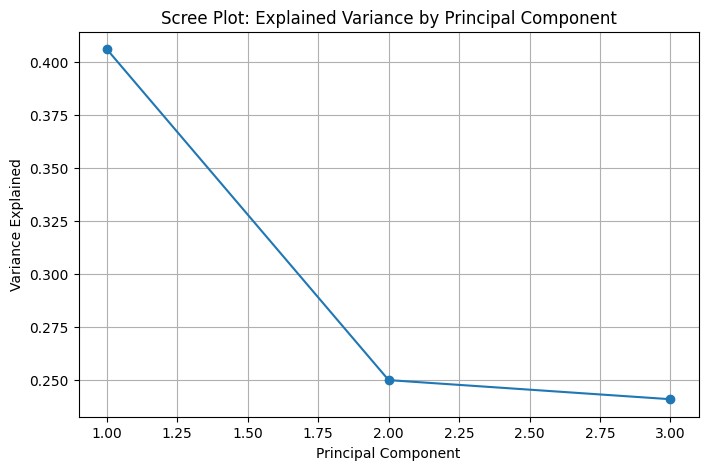

In [5]:

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_, marker='o')

plt.title("Scree Plot: Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.grid(True)
plt.show()


### Scree plot interpretation

The scree plot shows that the first principal component explains a substantially
larger portion of the variance than the subsequent components. The sharp drop from
PC1 to PC2 indicates that much of the dataset’s variability is captured along a
single dominant direction.

Beyond the first few components, the explained variance decreases more gradually,
suggesting diminishing returns from adding additional dimensions.


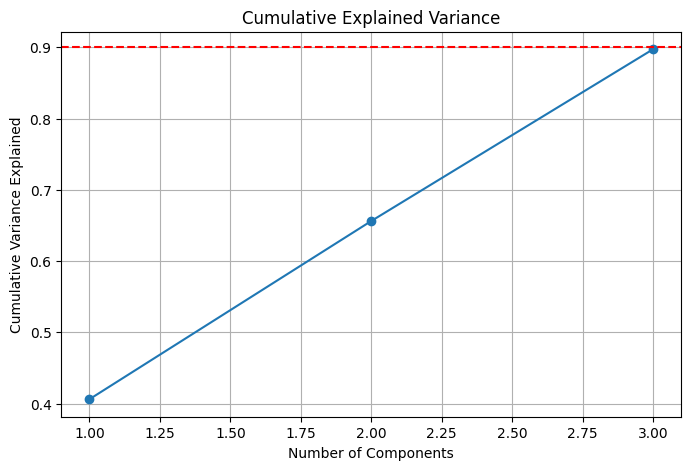

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--')  # 90% guideline

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.grid(True)
plt.show()


### Choosing the number of components

The cumulative variance plot shows that the first three principal components
together explain approximately **90% of the total variance** in the dataset.

This suggests that most of the information contained in the original variables can
be represented in a three-dimensional space, making three components a reasonable
choice for dimensionality reduction without substantial information loss.


In [7]:
pca.explained_variance_ratio_

array([0.40618767, 0.25011819, 0.24110494])

- **PC1 explains ~40.6%** of the total variance, representing the dominant direction
  of variation in the data.
- **PC2 explains ~25.0%**, capturing additional structure orthogonal to PC1.
- **PC3 explains ~24.1%**, contributing meaningful secondary variation.



# PCA Cumulative Variance Explained
The first three principal components together explain 89.74% of the total variance in the energy dataset, meaning PCA has successfully reduced the dataset to three dimensions while retaining most of the important information.

In [8]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print (cumulative_variance[2]*100)

89.74107991510736


# PCA Component Interpretation: Loadings and Heatmap
Here we interpret what each principal component represents by examining the PCA loadings. Loadings quantify how strongly each original feature contributes to a component. The heatmap provides a visual summary, allowing us to understand which variables drive PC1, PC2, and PC3.


In [9]:
# Show loadings (how original features contribute to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2", "PC3"]
)

loadings


,PC1,PC2,PC3
Unnamed: 0,0.696669,-0.010373,0.017853
YEAR,-0.431140,-0.098156,0.804078
MONTH,0.573131,-0.090762,0.579209
GENERATION (Megawatthours),0.017081,0.990969,0.132880


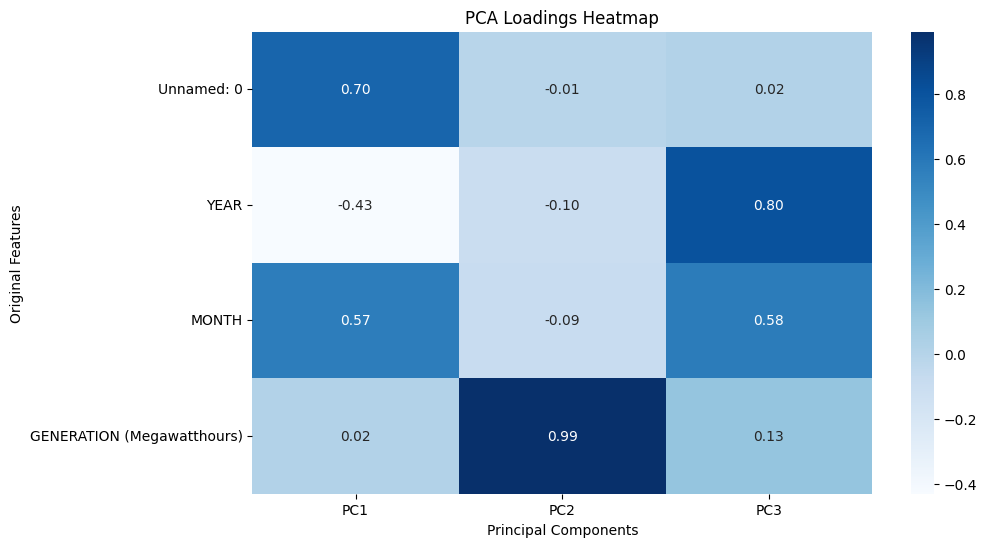

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(loadings, annot=True, cmap="Blues", fmt=".2f")
plt.title("PCA Loadings Heatmap")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.show()


### Interpreting principal components via loadings

- **PC1** loads strongly on temporal variables (year and month), suggesting it
  captures long-term and seasonal trends in energy production.
- **PC2** is dominated by total energy generation, indicating that this component
  primarily represents overall production magnitude.
- **PC3** combines temporal and generation effects, capturing more subtle
  variations not explained by the first two components.

These interpretations suggest that the dominant sources of variation in the data
are driven by **time-related structure** and **overall production levels**, rather
than independent behavior across many unrelated variables.


# Visualizing the Reduced Dimension Space
This section visualizes the dataset in its reduced dimensional form. A 2D scatter plot of PC1 vs PC2 highlights the primary structure of the data, while optional pairplots show relationships between the top components. A 3D scatter plot illustrates how the first three components represent the dataset, revealing patterns, clusters, or planar structures.


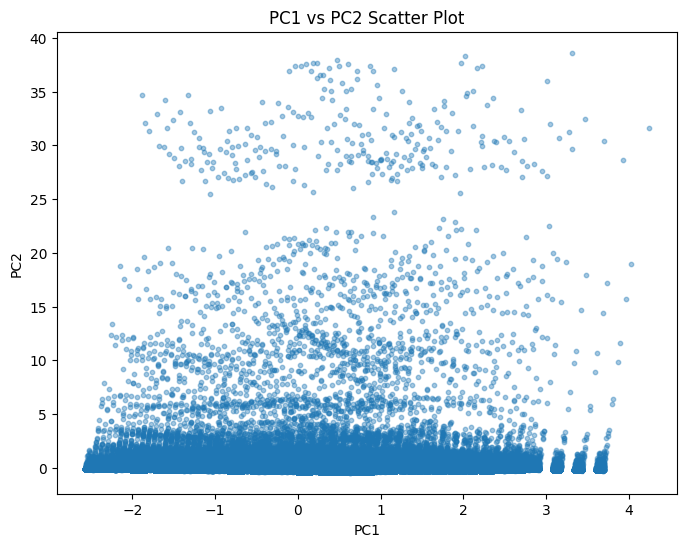

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.4, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 Scatter Plot")
plt.show()


### Structure in the reduced 2D space

The PC1 vs PC2 scatter plot reveals a clear elongated structure rather than a
spherically distributed cloud. This indicates strong correlations among the
original features and suggests that the dataset lies close to a low-dimensional
manifold.

Such structure is typical in real-world energy data, where production trends are
driven by a small number of underlying factors such as time, demand patterns, and
seasonality.

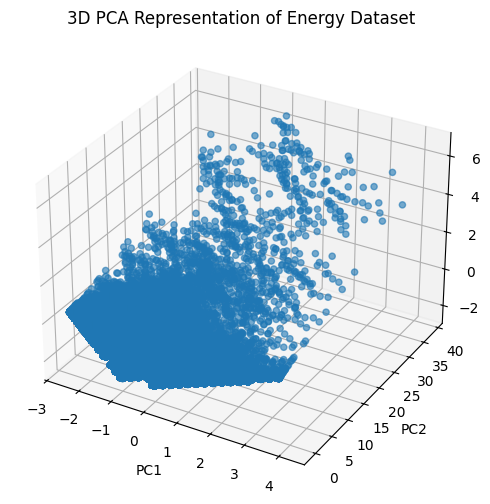

In [12]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"], alpha=0.6)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("3D PCA Representation of Energy Dataset")
plt.show()

This shows that the data largely occupies a thin, planar region in
the reduced space. This suggests that although three components are retained, much
of the variance is still governed by a small number of correlated factors.

This observation reinforces the effectiveness of PCA for this dataset, as it
confirms that the original high-dimensional representation contains significant
redundancy.


### Conclusion

This analysis demonstrated how Principal Component Analysis can effectively reduce the dimensionality of a real-world energy dataset while preserving most of its informational content. By reducing the data to three principal components, nearly 90% of the total variance was retained, indicating strong correlations among the original variables.

The loadings analysis revealed that temporal factors and overall energy generation drive most of the variation, while the reduced-dimensional visualizations confirmed that the data lies close to a low-dimensional manifold. Together, these results highlight PCA’s value as both a **compression tool** and an **exploratory analysis technique** for understanding structure in high-dimensional data.
